# Análise Exploratória de E-Commerce Brasileiro (Olist)

Análise de dados reais de um marketplace brasileiro com mais de 100 mil pedidos realizados entre 2016 e 2018. O objetivo é identificar padrões de vendas, comportamento de clientes e fatores que influenciam a satisfação do consumidor.

**Dataset:** [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


sns.set_style('whitegrid')

In [36]:
orders = pd.read_csv('C:/Users/eduar/projetos/analise-ecommerce-brasil/data/olist_orders_dataset.csv')
items = pd.read_csv('C:/Users/eduar/projetos/analise-ecommerce-brasil/data/olist_order_items_dataset.csv')
payments = pd.read_csv('C:/Users/eduar/projetos/analise-ecommerce-brasil/data/olist_order_payments_dataset.csv')
reviews = pd.read_csv('C:/Users/eduar/projetos/analise-ecommerce-brasil/data/olist_order_reviews_dataset.csv')
customers = pd.read_csv('C:/Users/eduar/projetos/analise-ecommerce-brasil/data/olist_customers_dataset.csv')
sellers = pd.read_csv('C:/Users/eduar/projetos/analise-ecommerce-brasil/data/olist_sellers_dataset.csv')
products = pd.read_csv('C:/Users/eduar/projetos/analise-ecommerce-brasil/data/olist_products_dataset.csv')
geolocation = pd.read_csv('C:/Users/eduar/projetos/analise-ecommerce-brasil/data/olist_geolocation_dataset.csv')
category = pd.read_csv('C:/Users/eduar/projetos/analise-ecommerce-brasil/data/product_category_name_translation.csv')

## 1. Visão Geral dos Dados

In [37]:
datasets = {
    'orders': orders,
    'items': items,
    'payments': payments,
    'reviews': reviews,
    'customers': customers,
    'sellers': sellers,
    'products': products,
    'geolocation': geolocation,
    'category': category
}

for nome, df in datasets.items():
    print(f"{nome}: {df.shape[0]} linhas, {df.shape[1]} colunas")

orders: 99441 linhas, 8 colunas
items: 112650 linhas, 7 colunas
payments: 103886 linhas, 5 colunas
reviews: 99224 linhas, 7 colunas
customers: 99441 linhas, 5 colunas
sellers: 3095 linhas, 4 colunas
products: 32951 linhas, 9 colunas
geolocation: 1000163 linhas, 5 colunas
category: 71 linhas, 2 colunas


In [38]:
print(customers.columns)

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')


**Limpeza e visão geral dos dados**

Orders tem 4 colunas de data com tipo objeto, devemos converter para datetime.
Além disso, veridiciamos o número de dados nulos emcada tabela.

In [39]:
#Precisamos organizar a coluna de datas de orders, pois está em formato de string.

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])
items['shipping_limit_date'] = pd.to_datetime(items['shipping_limit_date'])
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'])

#Contagem de linhas nulas nos dataframes.
for nome, df in datasets.items():
    nulos = df.isna().sum()
    nulos = nulos[nulos > 0].sort_values(ascending=False)


**Linhas Nulas**

Temos linhas núlas nas datas de entrega, pois são pedidos ainda não entregues por qualquer motivo (pedido em envio, cancelado, em processo e etc).

Temos muitas linhas nulas no dataframe de comentários dos pedidos, principalmente nos sem titulos e sem mensagem. Isso ocorre pois nem todos os clientes que compram colocam suas avaliações.

Temos um pequeno número de linhas nulas sobre informações de produtos, que pode ser um problema futuro, é o que devemos tratar antes de utilizar os dados.

In [40]:
#vamos ver os pedidos, items (pode existir mais de um item por pedido), pagamentos, avaliações e produtos.
df = orders.merge(customers, on = 'customer_id')
df = df.merge(items, on = 'order_id')
df = df.merge(payments, on = 'order_id')
df = df.merge(reviews, on = 'order_id')
df = df.merge(products, on='product_id')
#Vamos olhar apenas os pedidos já recebidos pelo cliente
df = df[df['order_status'] == 'delivered']

**2- Análise Temporal**

Vamos ver como foi a evolução temporal do número de pedidos, receita bruta e ticket médio.

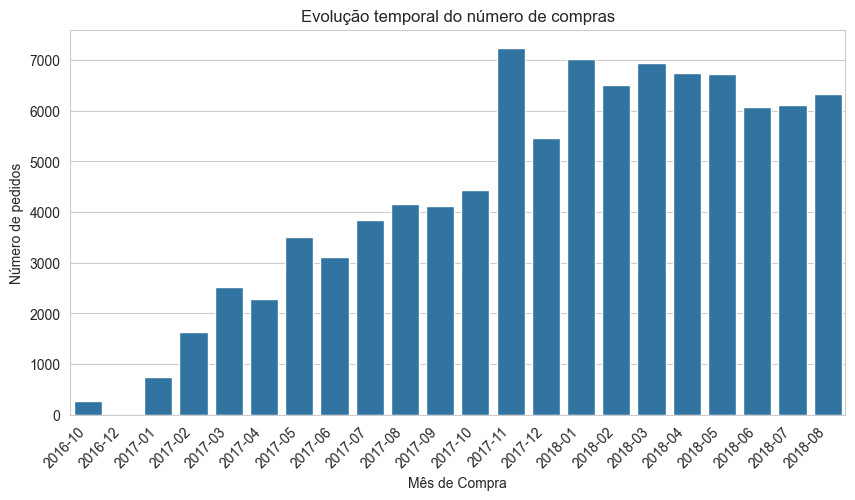

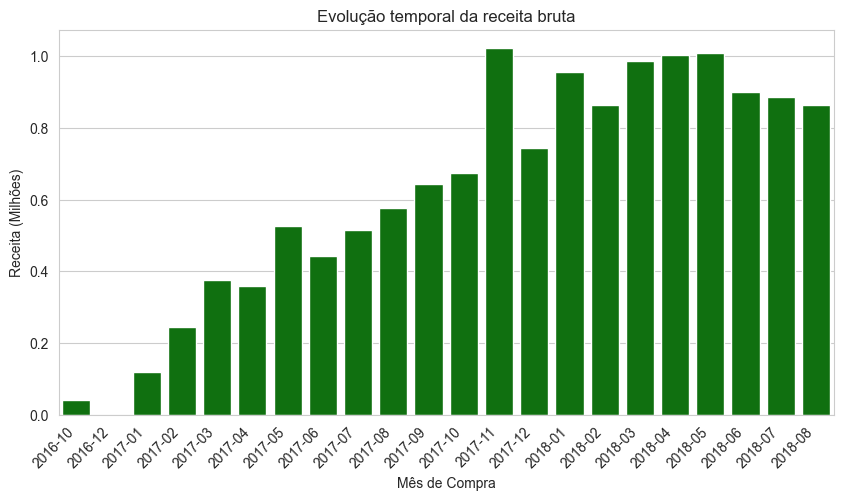

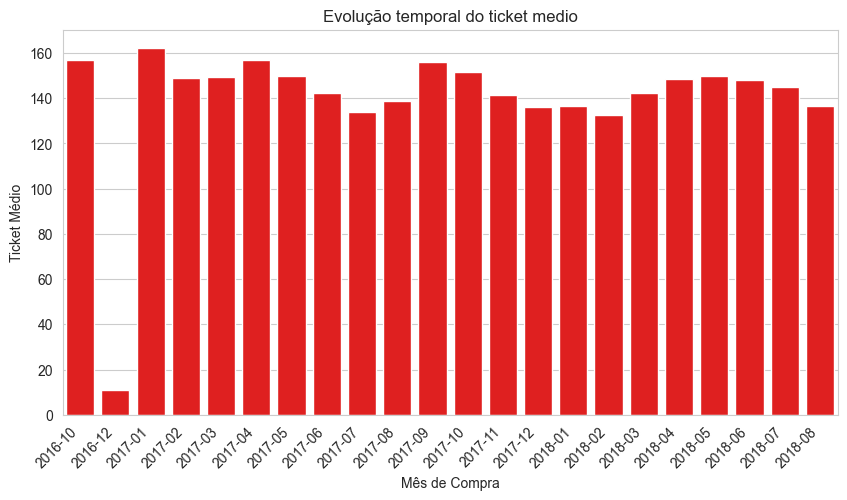

In [41]:
#Evolução temporal do número de pedidos
df['mes_compra'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)
mes_compra = df.groupby(by='mes_compra', as_index=False)['order_id'].nunique()

plt.figure(figsize=(10,5))
sns.barplot(mes_compra, x='mes_compra', y='order_id')
plt.title('Evolução temporal do número de compras')
plt.xlabel('Mês de Compra')
plt.ylabel('Número de pedidos')
plt.xticks(rotation=45, ha='right')
plt.show()

#Evolução temporal da receita bruta total
mes_compra_total = df.groupby(by='mes_compra', as_index=False)['price'].sum()
mes_compra_total['price'] /= 1E6
plt.figure(figsize=(10,5))
sns.barplot(mes_compra_total, x='mes_compra', y='price', color='green')
plt.title('Evolução temporal da receita bruta')
plt.xlabel('Mês de Compra')
plt.ylabel('Receita (Milhões)')
plt.xticks(rotation=45, ha='right')
plt.show()

#Evolução do Ticket Médio (receita por pedido):

ticket = df.groupby('mes_compra', as_index=False).agg(
    receita=('price', 'sum'),
    pedidos=('order_id', 'nunique')
)
ticket['ticket_medio'] = ticket['receita'] / ticket['pedidos']
plt.figure(figsize=(10,5))
sns.barplot(ticket, x='mes_compra', y='ticket_medio', color='red')
plt.title('Evolução temporal do ticket medio')
plt.xlabel('Mês de Compra')
plt.ylabel('Ticket Médio')
plt.xticks(rotation=45, ha='right')
plt.show()


**Conclusão**

Temos um aumento linear do número de pedidos e da receita bruta entre Out/2016 e Mar/2018, com uma estabilidade após esse período. O mês de Novembro de 2017 teve um crescimento acima do padrão, provavelmente causado por um crescimento de promoções na Black Friday. Além disso, ao olhar a evolução temporal do Ticket Médio, vemos que há poucas mudanças, concluindo que o aumento na receita é dada exclusivamente pelo aumento de pedidos nesse período.

**3- Análise Geográfica**

Buscamos acompanhar as vendas em cada estado do país. Para isso, vamos fazer 4 análises:

    1- Número de pedidos e receita bruta de compras por estado

    2- Número de vendedores e receita bruta de vendas por estado

    3- Relação entre compra e venda em cada estado

A pergunta a ser respondida é quais os estados vendem mais que compram e vice-versa. Dessa maneira, é possível entender a importação e exportação de produtos dentro do país, criando estratégias para buscar novos vendedores ou novos compradores em diferentes estados.

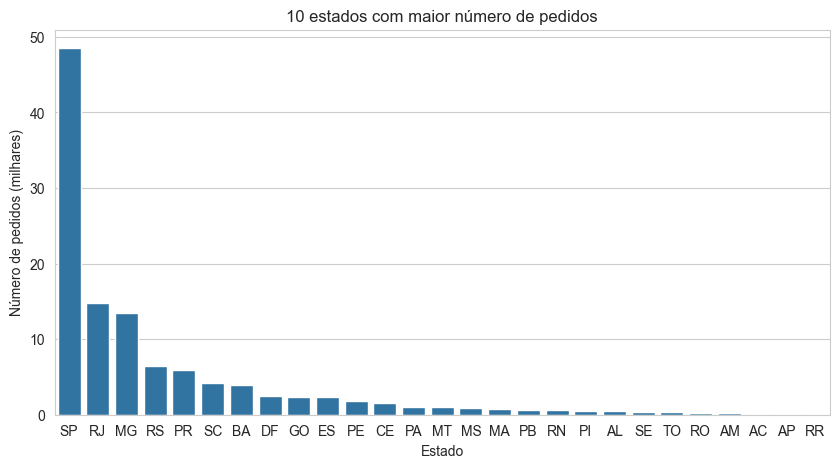

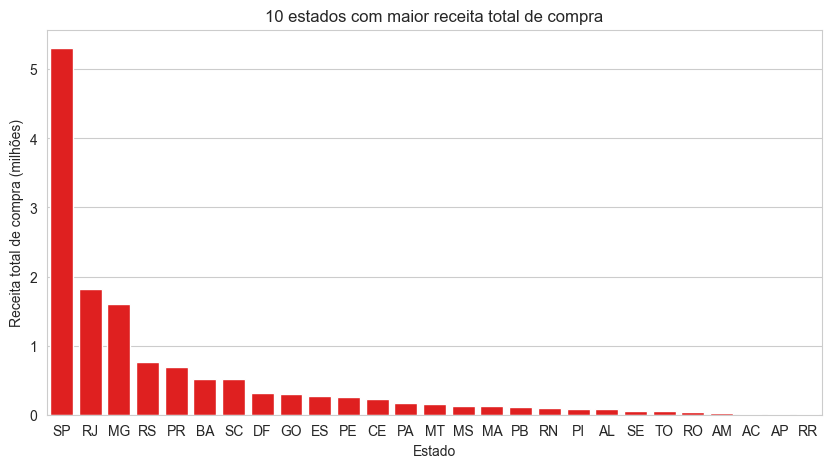

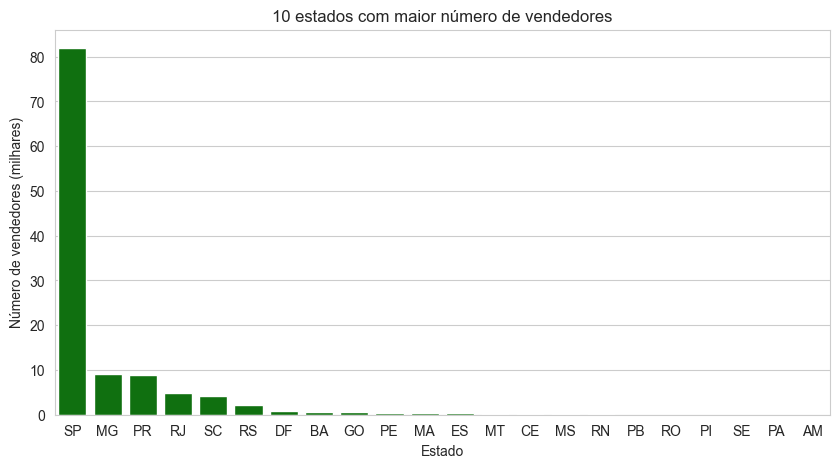

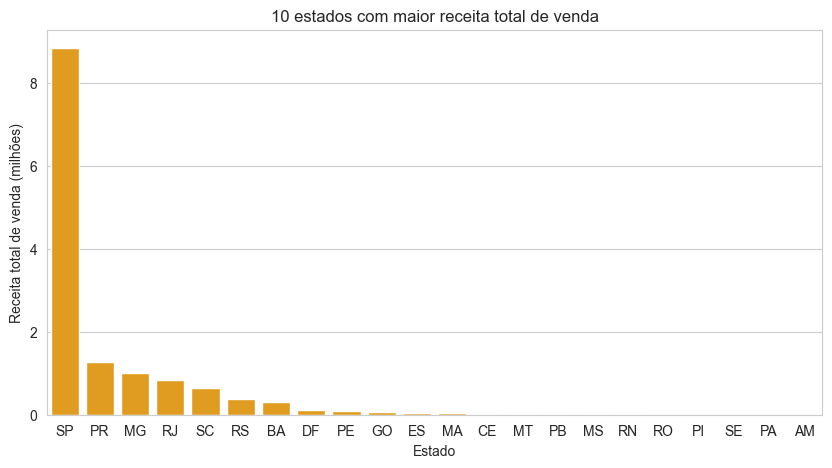

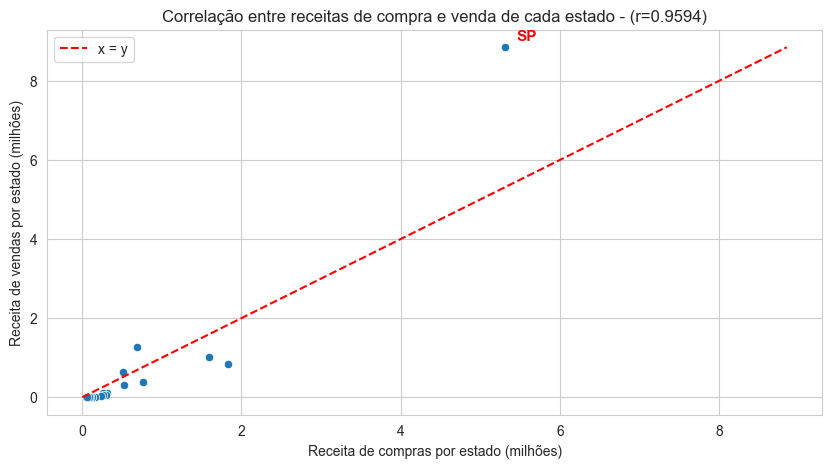

In [42]:
#---- Compras por estado
compras = df.groupby(by='customer_state', as_index=False)['order_id'].count().rename(columns={'order_id':'numero_de_pedidos'})
compras = compras.sort_values('numero_de_pedidos', ascending = False)
compras['numero_de_pedidos'] /=1000

plt.figure(figsize=(10,5))
sns.barplot(data=compras, x='customer_state', y='numero_de_pedidos')
plt.title('10 estados com maior número de pedidos')
plt.xlabel('Estado')
plt.ylabel('Número de pedidos (milhares)')
plt.show()

#---- Receita de compra por estado
compras = df.groupby(by='customer_state', as_index=False)['price'].sum().rename(columns={'price':'receita_compras'})
compras = compras.sort_values('receita_compras', ascending = False)
compras['receita_compras'] /= 1E6

plt.figure(figsize=(10,5))
sns.barplot(data=compras, x='customer_state', y='receita_compras', color='red')
plt.title('10 estados com maior receita total de compra')
plt.xlabel('Estado')
plt.ylabel('Receita total de compra (milhões)')
plt.show()

#---- Vendedores por estado
df_sellers = sellers.merge(df, on='seller_id')
vendas = df_sellers.groupby(by='seller_state', as_index=False)['seller_id'].count().rename(columns={'seller_id':'numero_de_vendedores'})
vendas = vendas.sort_values('numero_de_vendedores', ascending = False)
vendas['numero_de_vendedores'] /= 1000

plt.figure(figsize=(10,5))
sns.barplot(data=vendas, x='seller_state', y='numero_de_vendedores', color='green')
plt.title('10 estados com maior número de vendedores')
plt.xlabel('Estado')
plt.ylabel('Número de vendedores (milhares)')
plt.show()

#---- Receitas de venda por estado
vendas = df_sellers.groupby(by='seller_state', as_index=False)['price'].sum().rename(columns={'price':'receita_vendas'})
vendas = vendas.sort_values('receita_vendas', ascending = False)
vendas['receita_vendas'] /= 1E6

plt.figure(figsize=(10,5))
sns.barplot(data=vendas, x='seller_state', y='receita_vendas', color='orange')
plt.title('10 estados com maior receita total de venda')
plt.xlabel('Estado')
plt.ylabel('Receita total de venda (milhões)')
plt.show()

#Correlação entre receitas de compra e venda
comparacao = compras.merge(vendas, 
                           left_on='customer_state', 
                           right_on='seller_state', 
                           how='outer')
#Alguns estados não tem venda, por isso deixei apenas os maiores e exlui esses.
comparacao = comparacao.sort_values('receita_vendas',ascending=False).head(20)
r, p = stats.pearsonr(comparacao['receita_compras'], comparacao['receita_vendas'])

plt.figure(figsize=(10,5))
sns.scatterplot(data=comparacao, x='receita_compras',  y='receita_vendas')
max_val = max(comparacao['receita_compras'].max(), comparacao['receita_vendas'].max())
sp = comparacao[comparacao['customer_state'] == 'SP']
plt.annotate('SP', (sp['receita_compras'].values[0], sp['receita_vendas'].values[0]),
             textcoords="offset points", xytext=(8, 5), fontsize=11, fontweight='bold', color='red')
plt.plot([0, max_val], [0, max_val], 'r--', label='x = y')
plt.legend()
plt.title(f'Correlação entre receitas de compra e venda de cada estado - (r={r:.4f})')
plt.xlabel('Receita de compras por estado (milhões)')
plt.ylabel('Receita de vendas por estado (milhões)')
plt.show()


**Conclusões**

-> Existe forte correlação entre receita de compra e venda por estado (r = 0.93)

-> O que a linha x = y revela (quais estados são consumidores líquidos vs produtores líquidos). Estados acima da linha vendem mais do que compram e estados abaixo da linha compram mais do que vendem.

-> São Paulo concentra uma receita de compra e venda muito maior que de outros estados. Ainda assim, é possível criar estratégias de aumento de compradores internamente.

-> Existem diversos estados com receita maior de venda do que compra, sendo interessante aumentar a quantidade de vendedores.

**4 - Satisfação do Cliente**

Aqui vamos ver a distribuição de avaliações dos clientes em cada compra e tentar entender quais métricas mais impactam na nota final. Para isso, vamos comparar avaliações de pedidos com e sem atraso de entrega.

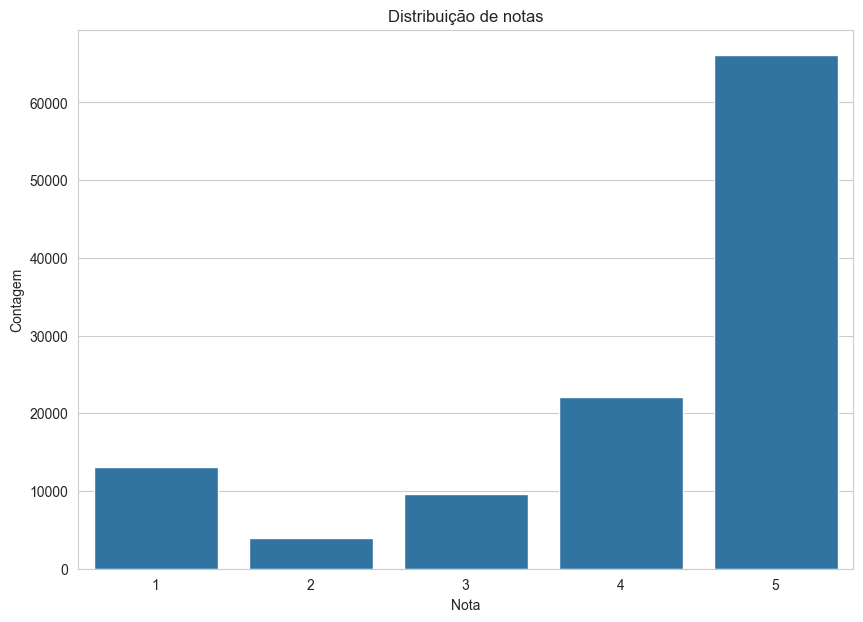

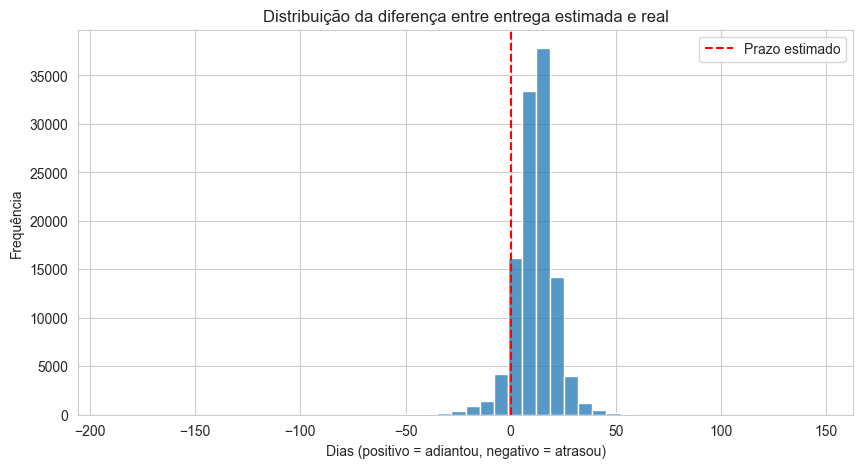

A média de avaliações dos pedidos no prazo é 4.2087 e a média de avaliações de pedidos atrasados é 2.5470
Ao comparar as médias, temos um teste t com valor -92.1716 e p valor de 0.0000


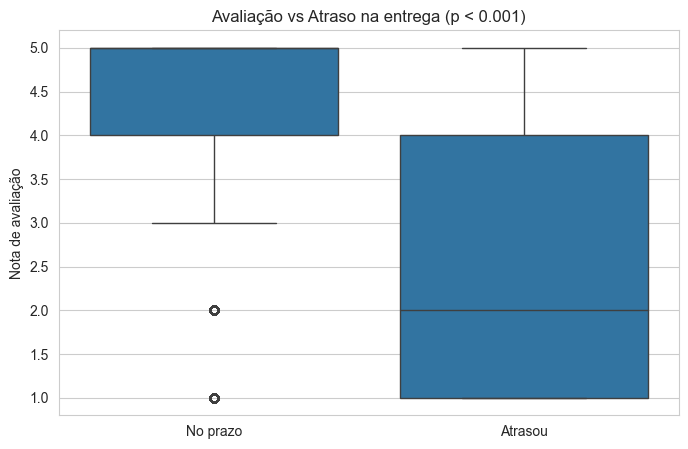

In [43]:
contagem_avaliacoes = df.groupby('review_score', as_index=False)['order_id'].count().rename(columns={'order_id':'contagem_avaliacoes'})

plt.figure(figsize=(10,7))
sns.barplot(contagem_avaliacoes, x='review_score', y='contagem_avaliacoes')
plt.title('Distribuição de notas')
plt.xlabel('Nota')
plt.ylabel('Contagem')
plt.show()

#Vamos visualizar a diferença entre o dia previsto de entrega e o dia real de entrega, ver se há atrasos ou adiantamentos significativos
df['dias_atraso'] = (df['order_estimated_delivery_date']-df['order_delivered_customer_date']).dt.days
data_atraso = df.groupby('dias_atraso', as_index=False)['order_id'].count().rename(columns={'order_id':'contagem_atraso'})

#Temos uma coluna que separa o que atrasou e o que não atrasou
def atrasou(dias_atraso):
    if dias_atraso<0:
        return True
    else:
        return False

df['atrasou'] = df['dias_atraso'].apply(atrasou)

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='dias_atraso', bins=50)
plt.axvline(x=0, color='red', linestyle='--', label='Prazo estimado')
plt.title('Distribuição da diferença entre entrega estimada e real')
plt.xlabel('Dias (positivo = adiantou, negativo = atrasou)')
plt.ylabel('Frequência')
plt.legend()
plt.show()

pedidos_atrasados = df[df['atrasou'] == True]['review_score']
pedidos_prazo = df[df['atrasou'] == False]['review_score']

t_stat, p_valor = stats.ttest_ind(pedidos_atrasados, pedidos_prazo, equal_var=False)
print(f'A média de avaliações dos pedidos no prazo é {pedidos_prazo.mean():.4f} e a média de avaliações de pedidos atrasados é {pedidos_atrasados.mean():.4f}')
print(f'Ao comparar as médias, temos um teste t com valor {t_stat:.4f} e p valor de {p_valor:.4f}')

#Boxplot comparativo
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='atrasou', y='review_score')
plt.xticks([0, 1], ['No prazo', 'Atrasou'])
plt.title(f'Avaliação vs Atraso na entrega (p < 0.001)')
plt.xlabel('')
plt.ylabel('Nota de avaliação')
plt.show()

### Conclusões

-> Pedidos entregues no prazo têm nota média de 4.21, contra 2.55 dos atrasados.

-> A diferença é estatisticamente significativa (p < 0.001), confirmando que atraso impacta diretamente a satisfação.

-> Recomendação: além de melhorar a logística, ajustar o prazo estimado de entrega para valores mais conservadores pode reduzir a percepção de atraso sem custo adicional.

**5 Comparações de logistica entre Estados**

Vamos fazer uma comparação geolocalizada nas diferentes macroregiões do Brasil. Para isso, vamos ver o tempo médio de entrega e a taxa de pedidos atrasados por estado e, para isso, vamos comparar se há correlação com a média de avaliações.

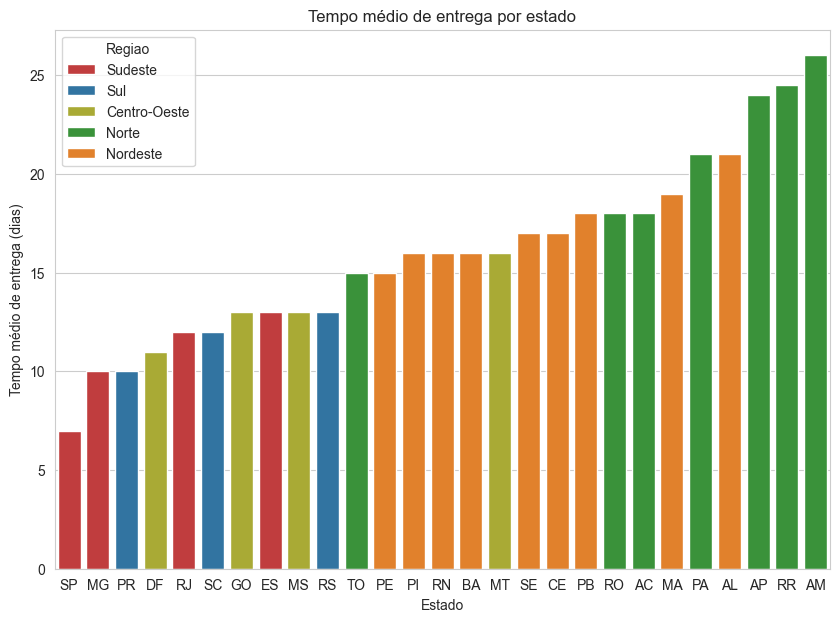

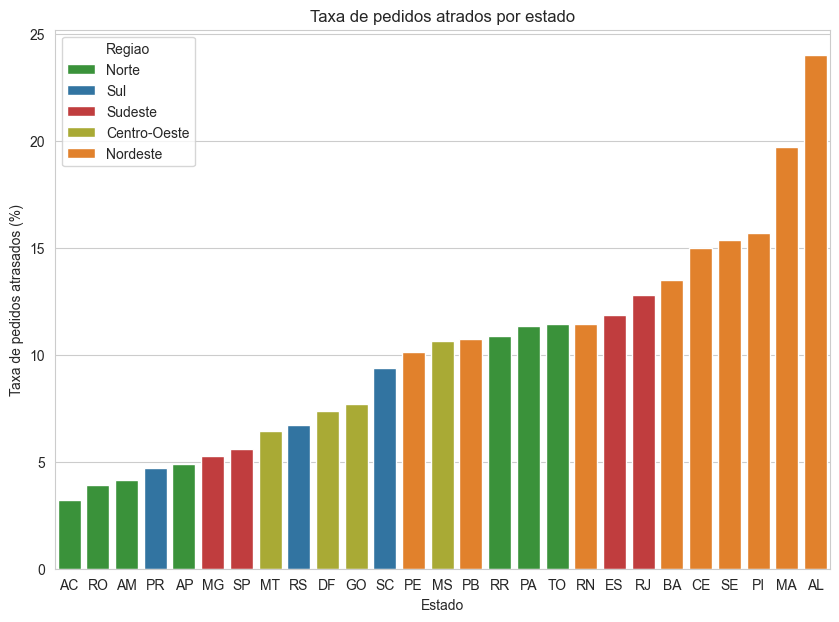

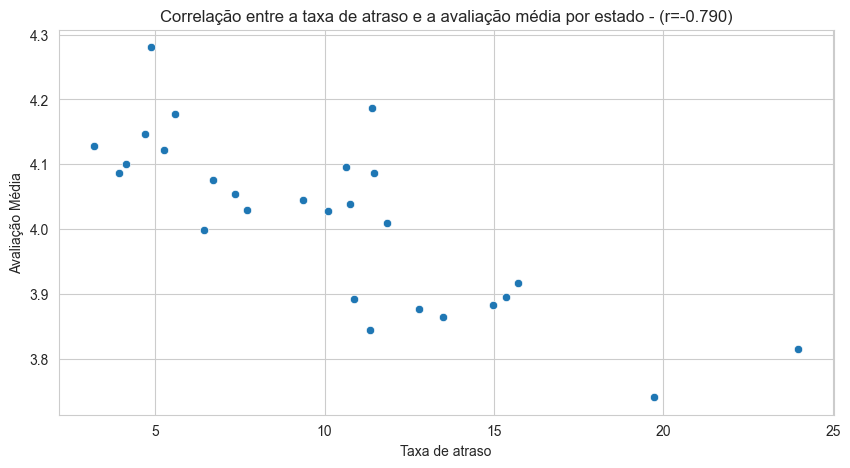

In [44]:
#---- Tempo de entrega por estado
df['tempo_entrega'] = (df['order_delivered_customer_date']-df['order_purchase_timestamp']).dt.days
tempo_entrega = df.groupby('customer_state', as_index=False)['tempo_entrega'].median()
tempo_entrega = tempo_entrega.sort_values('tempo_entrega')

norte = ['AC', 'RR', 'RO', 'AM', 'AP', 'TO', 'PA']
nordeste = ['AL', 'PE', 'MA', 'BA', 'SE', 'RN', 'CE', 'PI', 'PB']
sul = ['PR', 'SC', 'RS']
sudeste = ['SP', 'RJ', 'MG', 'ES']
centro_oeste = ['MT', 'MS', 'DF', 'GO']

mapeamento_regiao = {}
for uf in norte:
  mapeamento_regiao[uf] = 'Norte'
for uf in nordeste:
  mapeamento_regiao[uf] = 'Nordeste'
for uf in sul:
  mapeamento_regiao[uf] = 'Sul'
for uf in sudeste:
  mapeamento_regiao[uf] = 'Sudeste'
for uf in centro_oeste:
  mapeamento_regiao[uf] = 'Centro-Oeste'

tempo_entrega['Regiao'] = tempo_entrega['customer_state'].map(
    mapeamento_regiao
)

cores_regioes = {
    'Norte': '#2ca02c',
    'Nordeste': '#ff7f0e',  
    'Centro-Oeste': '#bcbd22',  
    'Sudeste': '#d62728',  
    'Sul': '#1f77b4',  
}

plt.figure(figsize=(10,7))
sns.barplot(tempo_entrega, x='customer_state', y='tempo_entrega', hue='Regiao', dodge=False, palette=cores_regioes)
plt.title('Tempo médio de entrega por estado')
plt.xlabel('Estado')
plt.ylabel('Tempo médio de entrega (dias)') #na verdade é a mediana, mas média fica mais fácil de uma pessoa qualquer entender
plt.show()

#-------------- Taxa de atraso por estado
taxa_atraso = df.groupby(by='customer_state',as_index=False)['atrasou'].mean().rename(columns={'atrasou':'taxa_atraso'})
taxa_atraso['taxa_atraso'] *= 100
taxa_atraso = taxa_atraso.sort_values('taxa_atraso')
taxa_atraso['Regiao'] = taxa_atraso['customer_state'].map(
    mapeamento_regiao
)

plt.figure(figsize=(10,7))
sns.barplot(taxa_atraso, x='customer_state', y='taxa_atraso', hue='Regiao', dodge=False, palette=cores_regioes)
plt.title('Taxa de pedidos atrados por estado')
plt.xlabel('Estado')
plt.ylabel('Taxa de pedidos atrasados (%)')
plt.show()

#--------------- Correlação entre avaliações e taxa de atraso por estado

notas_por_estado = df.groupby('customer_state', as_index=False)['review_score'].mean()
taxa_atraso = taxa_atraso.sort_index()

r, p_valor = stats.pearsonr(taxa_atraso['taxa_atraso'], notas_por_estado['review_score'])

plt.figure(figsize=(10,5))
sns.scatterplot(x=taxa_atraso['taxa_atraso'],  y=notas_por_estado['review_score'])
plt.title(f'Correlação entre a taxa de atraso e a avaliação média por estado - (r={r:.3f})')
plt.xlabel('Taxa de atraso')
plt.ylabel('Avaliação Média')
plt.show()


**Conclusões**

-> Os estados da região Sul e Sudeste são os com menor tempo médio de entrega, enquanto os estados do norte e nordeste tem um tempo médio de entrega maior.

-> A região nordeste se mostra a região do país com maior taxa de atraso, enquanto para as outras regiões há uma variação da taxa entre os estados.

-> Existe uma forte correlação negativa (r = -0.790) entre a taxa de atraso e a avaliação média entre os estados. Ou seja, confirmamos de maneira independente que o atraso nas entregas impacta negativamente nas avaliações dos produtos. 

**6 - Categorias de produto vs Satisfação**

Vamos explorar quais as características são mais relevantes para os produtos terem uma taxa de satisfação alta ou baixa. Para isso, vamos olhar para as categorias com maior e menor avaliação e ver quais as métricas mais importantes em cada caso.

Melhores categorias:
                product_category_name  taxa_atraso
0                           alimentos     9.741551
1                   alimentos_bebidas     6.049822
2  construcao_ferramentas_ferramentas     4.950495
3                  eletrodomesticos_2     6.106870
4                     eletroportateis     5.743741
5                    fashion_calcados     5.597015
6              livros_interesse_geral     6.788991
7                     livros_tecnicos    10.861423
8                    malas_acessorios     5.069930
9                           papelaria     8.017208

Piores categorias:
     product_category_name  taxa_atraso
0                    audio    12.266667
1          cama_mesa_banho     7.984596
2            casa_conforto     9.341826
3          casa_construcao     8.025682
4  fashion_roupa_masculina     7.299270
5         moveis_decoracao     8.039262
6        moveis_escritorio     8.638444
7            moveis_quarto     6.722689
8              moveis_sala     7.58754

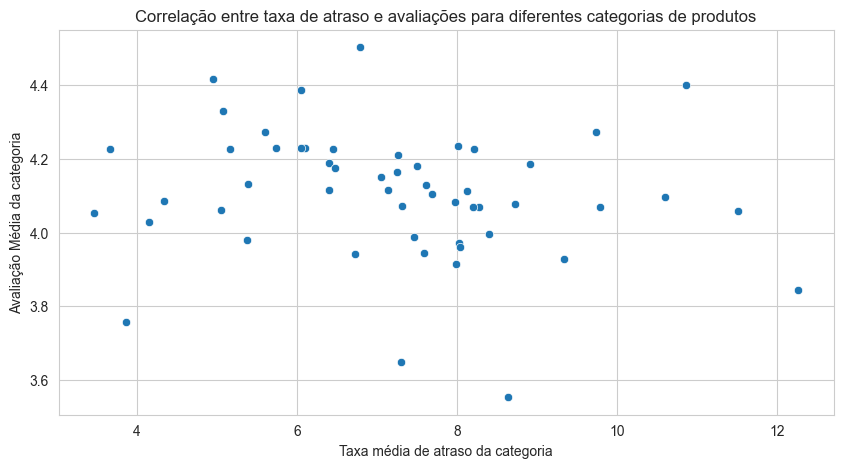

In [45]:
#Avaliação média por categorias de pedidos

avaliacao_media_categoria = df.groupby(by='product_category_name', as_index=False).agg(
    numero_avaliacoes=('review_score', 'count'),
    media=('review_score', 'mean'),
)
avaliacao_media_categoria = avaliacao_media_categoria[avaliacao_media_categoria['numero_avaliacoes'] > 100]

#Filtrando os produtos 10 produtos com maiores e menores avaliações
maiores_avaliacoes = avaliacao_media_categoria.sort_values('media', ascending=False).head(10)
menores_avaliacoes = avaliacao_media_categoria.sort_values('media',ascending=True).head(10)

df_boas = df[df['product_category_name'].isin(maiores_avaliacoes['product_category_name'])]
df_ruins = df[df['product_category_name'].isin(menores_avaliacoes['product_category_name'])]

taxa_boas = df_boas.groupby('product_category_name', as_index=False)['atrasou'].mean()
taxa_boas['atrasou'] *= 100
taxa_boas = taxa_boas.rename(columns={'atrasou': 'taxa_atraso'})
print("Melhores categorias:")
print(taxa_boas)

taxa_ruins = df_ruins.groupby('product_category_name', as_index=False)['atrasou'].mean()
taxa_ruins['atrasou'] *= 100
taxa_ruins = taxa_ruins.rename(columns={'atrasou': 'taxa_atraso'})
print("\nPiores categorias:")
print(taxa_ruins)

#Buscamos correlação entre a taxa de atraso e a avaliação de cada categoria.

taxa_por_cat = df.groupby('product_category_name', as_index=False)['atrasou'].mean()
taxa_por_cat['atrasou'] *= 100
taxa_por_cat = taxa_por_cat.rename(columns={'atrasou': 'taxa_atraso'})
cat_completo = avaliacao_media_categoria.merge(taxa_por_cat, on='product_category_name')

r, p = stats.pearsonr(cat_completo['taxa_atraso'], cat_completo['media'])
print(f"r = {r:.4f}, p = {p:.4f}")

plt.figure(figsize=(10,5))
sns.scatterplot(cat_completo, x='taxa_atraso', y='media')
plt.title('Correlação entre taxa de atraso e avaliações para diferentes categorias de produtos')
plt.xlabel('Taxa média de atraso da categoria')
plt.ylabel('Avaliação Média da categoria')
plt.show()

**6- Conclusão**

Vemos que não há correlação entre a taxa média de atraso e a avaliação média de cada categoria. Isso mostra que o que mais influencia na avaliação dos produtos são os próprios produtos. 

AS categorias de produtos com maior avaliação média são os mais fáceis e rápidos de transportar, como itens de papelaria, alimentos e eletrodomésticos. Enquanto as categorias de produtos com menor avaliação média são os complexos de transportar, como móveis.

## 7. Conclusões Gerais

### Principais insights

**Crescimento do marketplace:**
- A receita e o volume de pedidos cresceram de forma consistente entre 2016 e 2018, com pico em novembro/2017 (Black Friday).
- O ticket médio se manteve estável (~R$130-160), indicando que o crescimento foi impulsionado por novos clientes, não por aumento no valor das compras.

**Concentração geográfica:**
- São Paulo domina tanto em compras quanto em vendas, com uma concentração ainda maior no lado dos vendedores.
- Existe forte correlação entre receita de compra e venda por estado (r = 0.94), mas SP se destaca como exportador líquido de produtos para o restante do país.

**Impacto da logística na satisfação:**
- Pedidos atrasados têm nota média significativamente menor que os entregues no prazo (p < 0.001).
- Estados com maior taxa de atraso apresentam piores avaliações médias (r = -0.79).
- Recomendação: ajustar prazos estimados para valores mais conservadores pode reduzir a percepção de atraso sem custo adicional.

**Categorias de produto:**
- A diferença de satisfação entre categorias é significativa, mas não é explicada pela logística (r = -0.17, p = 0.23 entre taxa de atraso e nota por categoria).
- Produtos grandes e complexos (móveis, construção) têm piores avaliações, provavelmente por expectativa vs realidade e danos no transporte.

### Ferramentas utilizadas
- **Python:** pandas, matplotlib, seaborn, scipy, scikit-learn
- **SQL:** PostgreSQL
- **Estatística:** teste t, correlação de Pearson, p-valor

### Dados
[Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)